# 20: What Happens When the Crystal Can Lose Material?

The notebook introduces material loss visibly, audits V1's failed finite-regime hypothesis, and preserves V2's more important result: removed material becomes ordinary attachment opportunity again.


In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams,
    advance_one_step,
    attachment_probability,
    axial_to_xy,
    cell_keyed_uniform,
    frontier,
    hex_distance,
    initial_state,
    neighbors,
    run_crystal,
)

NOTEBOOK_PROFILE = os.environ.get("NOTEBOOK_PROFILE", "quick")
RUN_CANONICAL = os.environ.get("RUN_CANONICAL", "0") in {"1", "true", "True"}

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def mean_of(summary, key="mean"):
    return summary[key] if isinstance(summary, dict) and key in summary else summary

def audit(label, observed, source="canonical research artifact"):
    return {"label": label, "source": source, "observed": observed}

def plot_cells(ax, occupied, lost=None, selected=None, title=""):
    lost = lost or set()
    selected = selected or set()
    for cells, color, size, alpha in [(occupied, "#253494", 18, .85), (lost, "#b2182b", 30, .9), (selected, "#fdae61", 45, .95)]:
        if cells:
            xy = np.array([axial_to_xy(c) for c in cells])
            ax.scatter(xy[:,0], xy[:,1], s=size, c=color, alpha=alpha)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title)


In [2]:
EXPERIMENT = {
    "profile": NOTEBOOK_PROFILE,
    "run_canonical": RUN_CANONICAL,
    "new_mechanism": "material loss",
    "forbidden_words": ["repair", "regeneration", "healing", "maintenance", "homeostasis"],
}
EXPERIMENT


{'profile': 'quick',
 'run_canonical': False,
 'new_mechanism': 'material loss',
 'forbidden_words': ['repair',
  'regeneration',
  'healing',
  'maintenance',
  'homeostasis']}

## Mechanism: loss creates ordinary frontier opportunity


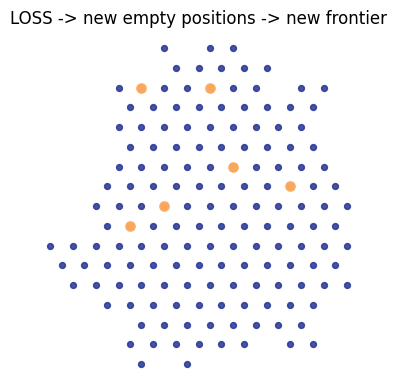

{'label': 'structural mechanism',
 'source': 'quick recomputed',
 'observed': {'lost_cells': 6,
  'lost_cells_now_frontier': 6,
  'new_frontier_sites': 6}}

In [3]:
rng = random.Random(20)
state = run_crystal([0.25] * 10, seed=20, max_radius=8)
occupied_before = set(state.occupied)
interior_candidates = [c for c in occupied_before if sum(nb in occupied_before for nb in neighbors(c)) >= 4]
lost = set(rng.sample(interior_candidates, 6))
occupied_after_loss = occupied_before - lost
new_frontier = frontier(occupied_after_loss, 8) - frontier(occupied_before, 8)
reusable = sorted(lost & frontier(occupied_after_loss, 8))
fig, ax = plt.subplots(figsize=(5, 4))
plot_cells(ax, occupied_after_loss, lost=lost, selected=new_frontier, title="LOSS -> new empty positions -> new frontier")
fig.tight_layout()
fig.savefig(FIG_DIR / "ch20-loss-creates-frontier-quick.png", bbox_inches="tight")
plt.show()
audit("structural mechanism", {
    "lost_cells": len(lost),
    "lost_cells_now_frontier": len(reusable),
    "new_frontier_sites": len(new_frontier),
}, source="quick recomputed")


## V1 artifact audit: naive perimeter/area balance failed


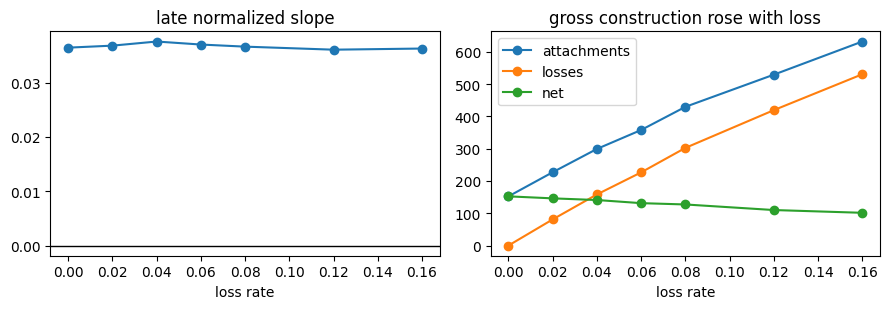

{'label': 'V1 finite-regime audit',
 'source': 'canonical research artifact',
 'observed': {'status': 'FAILED',
  'qualifying_nonzero_loss_rates': [],
  'mean_slope_range': [0.036080962930881325, 0.03758276955095493],
  'late_population_advantage_interior_minus_surface': 0.11089400874021672,
  'mean_holes_surface': 2.690104166666667,
  'mean_holes_interior': 29.825520833333332}}

In [4]:
sweep = load_json("research/digital-life/ch20-material-loss-v1/stage-02-loss-sweep.json")
placement = load_json("research/digital-life/ch20-material-loss-v1/stage-03-loss-placement.json")
verdict1 = load_json("research/digital-life/ch20-material-loss-v1/stage-04-verdict.json")
rates = [float(k) for k in sweep["by_rate"]]
slopes = [sweep["by_rate"][str(r)]["late_normalized_population_slope"]["mean"] for r in rates]
attachments = [sweep["by_rate"][str(r)]["late_mean_attachments"]["mean"] for r in rates]
losses = [sweep["by_rate"][str(r)]["late_mean_losses"]["mean"] for r in rates]
net = [sweep["by_rate"][str(r)]["late_mean_net"]["mean"] for r in rates]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(rates, slopes, marker="o"); ax[0].axhline(0, color="black", lw=1); ax[0].set(title="late normalized slope", xlabel="loss rate")
ax[1].plot(rates, attachments, marker="o", label="attachments"); ax[1].plot(rates, losses, marker="o", label="losses"); ax[1].plot(rates, net, marker="o", label="net")
ax[1].set(title="gross construction rose with loss", xlabel="loss rate"); ax[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "ch20-v1-loss-sweep-audit.png", bbox_inches="tight"); plt.show()
audit("V1 finite-regime audit", {
    "status": verdict1["status"],
    "qualifying_nonzero_loss_rates": verdict1["qualifying_nonzero_loss_rates"],
    "mean_slope_range": [min(slopes), max(slopes)],
    "late_population_advantage_interior_minus_surface": placement["late_population_advantage_interior_minus_surface"]["mean"],
    "mean_holes_surface": placement["mean_late_holes_surface"],
    "mean_holes_interior": placement["mean_late_holes_interior"],
}, source="canonical research artifact")


## V2 artifact audit: ledger observes first occupation vs reoccupation


In [5]:
noloss = load_json("research/digital-life/ch20-material-loss-v2/stage-01-no-loss.json")
pair = load_json("research/digital-life/ch20-material-loss-v2/stage-02-exact-pair.json")
verdict2 = load_json("research/digital-life/ch20-material-loss-v2/stage-04-verdict.json")
assert noloss["reoccupation_count_all_groups"] == 0
audit("V2 occupancy ledger", {
    "assertion_no_loss_reoccupation": noloss["reoccupation_count_all_groups"],
    "surface_reoccupation_per_loss": pair["surface"]["mean_reoccupation_per_loss"],
    "interior_reoccupation_per_loss": pair["interior"]["mean_reoccupation_per_loss"],
    "interior_minus_surface": verdict2["primary_mean_interior_minus_surface_reoccupation_per_loss"],
    "required_difference": verdict2["primary_sei"],
    "status": verdict2["status"],
    "surface_delay": pair["surface"]["mean_reoccupation_delay"],
    "interior_delay": pair["interior"]["mean_reoccupation_delay"],
}, source="canonical research artifact")


{'label': 'V2 occupancy ledger',
 'source': 'canonical research artifact',
 'observed': {'assertion_no_loss_reoccupation': 0,
  'surface_reoccupation_per_loss': 0.9363695679658072,
  'interior_reoccupation_per_loss': 0.9561405127844184,
  'interior_minus_surface': 0.01977094481861134,
  'required_difference': 0.15,
  'status': 'FAILED',
  'surface_delay': 1.563724089992582,
  'interior_delay': 1.0852403967101567}}

## Bounded claim

V1 and V2 finite-regime hypotheses remain failed. The preserved phenomenon is narrower and stronger: material removal creates attachment opportunity that ordinary growth rapidly reuses.

## Provenance

Current local book chapter: `content/books/digital-life/20-material-loss/index.md`

Research scripts: `ch20_digital_crystal_material_loss_v1.py`, `ch20_digital_crystal_material_loss_v2.py`

Canonical artifacts: `research/digital-life/ch20-material-loss-v1/`, `research/digital-life/ch20-material-loss-v2/`

Notebook figures: `ch20-loss-creates-frontier-quick.png`, `ch20-v1-loss-sweep-audit.png`

Execution mode: quick-recomputed + canonical-artifact-audit

## Claim Ledger

ASSERTION: no-loss reoccupation count equals zero.

FAILED: V1 finite near-stationary construction/loss regime; V2 predeclared interior-minus-surface reoccupation advantage.

SUPPORTED: ordinary loss opens attachment opportunity and most removed cells are rapidly reoccupied under the measured protocol.

UNTESTED: repair, regeneration, healing, maintenance, homeostasis.
